## Model Evaluation

In [1]:
import random
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from keras import models
import seaborn as sn

Classnames: 
0 baseball
1 basketball
2 beachballs
3 billiard ball
4 bowling ball
5 brass
6 buckeyballs
7 cannon ball
8 cricket ball
9 eyeballs


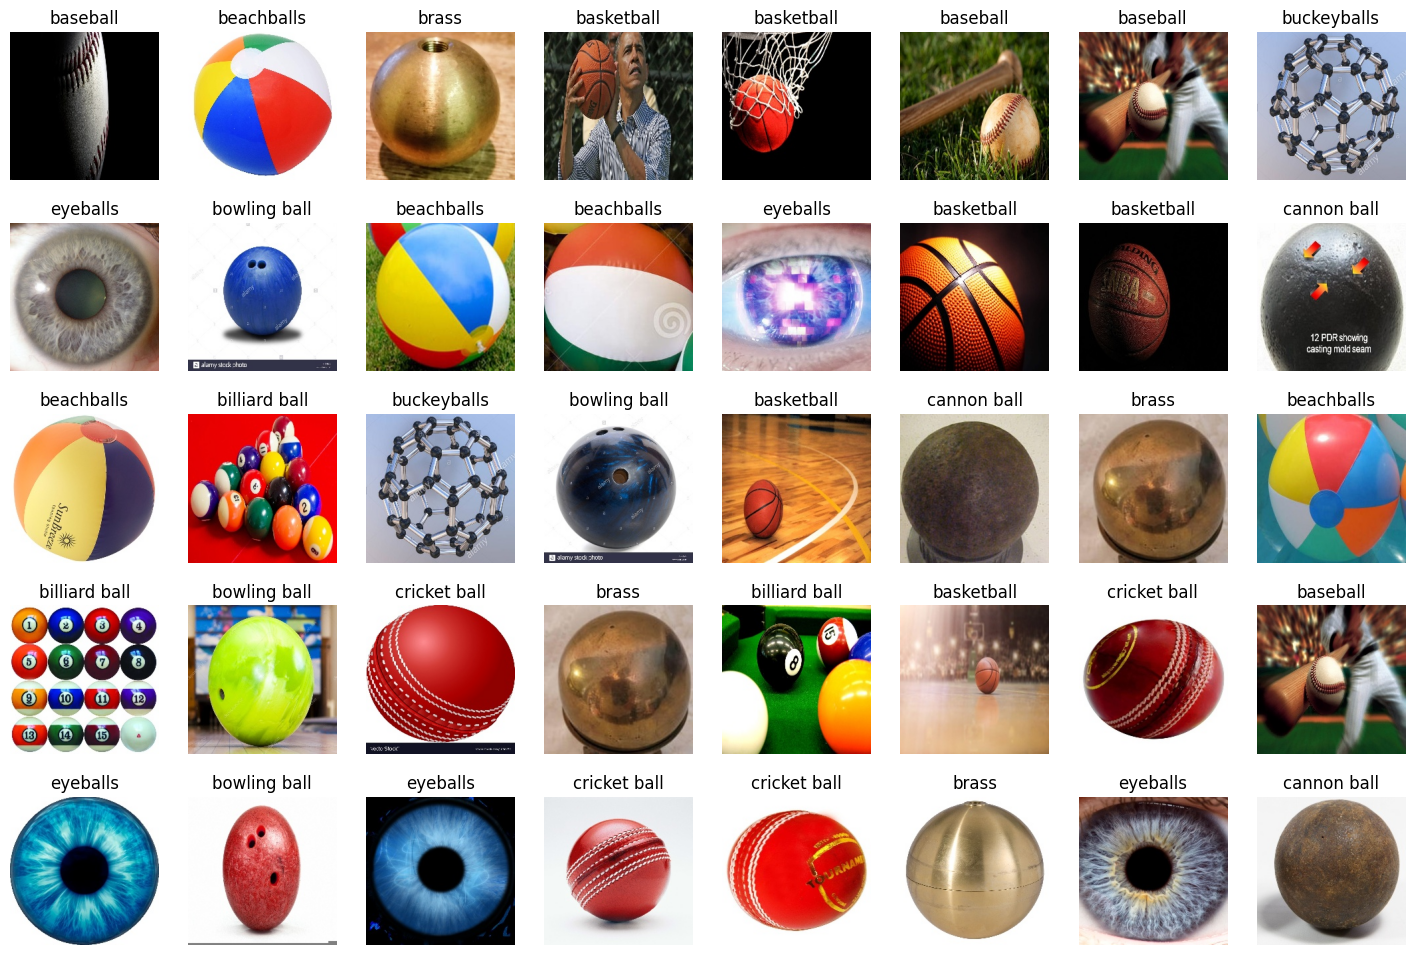

Found 1125 files belonging to 10 classes.
Found 200 files belonging to 10 classes.
Data batch shape: (64, 224, 224, 3)
Labels batch shape: (64, 10)
Take() Data batch shape: (64, 224, 224, 3)
Take() Labels batch shape: (64, 10)
['baseball', 'basketball', 'beachballs', 'billiard ball', 'bowling ball', 'brass', 'buckeyballs', 'cannon ball', 'cricket ball', 'eyeballs']


2025-11-24 23:57:53.837424: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


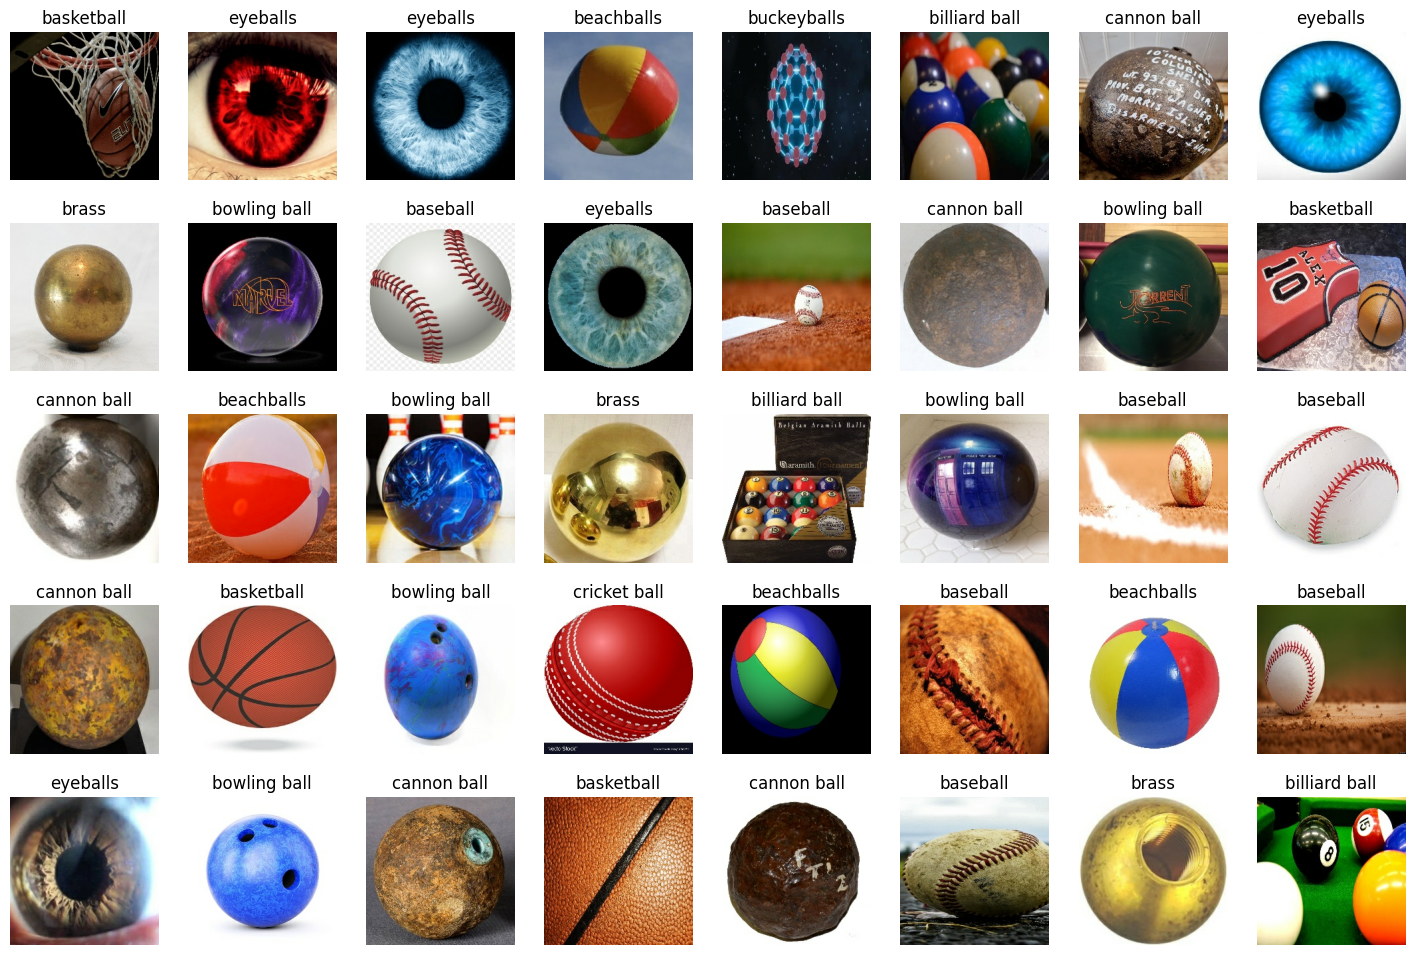

2025-11-24 23:57:54.307065: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [2]:
%run -i data_preprocessing.ipynb

In [3]:
# Import saved model
model = models.load_model("classification_model.keras")

In [4]:
valid_loss, valid_accuracy = model.evaluate(valid_dataset)
print(f"Validation Accuracy: {valid_accuracy}.3f")

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 502ms/step - accuracy: 0.6600 - loss: 1.7928
Validation Accuracy: 0.6600000262260437.3f


In [8]:
def visualise_predictions(dataset, model):
    numRows = 5
    numCols = 7

    plt.figure(figsize=(17, 12))

    classNames = dataset.class_names
    numMatches = 0

    for dataBatch, labelsBatch in dataset.take(1):
        predictions = model.predict(dataBatch)

        for idx in range(numRows * numCols):
            ax = plt.subplot(numRows, numCols, idx + 1)
            plt.axis("off")
            plt.imshow(dataBatch[idx].numpy().astype("uint8"))

            predictionIndex = tf.argmax(predictions[idx]).numpy()
            truthIndex = np.nonzero(labelsBatch[idx].numpy())

            title = (
                str(classNames[truthIndex[0][0]])
                + " : "
                + str(classNames[predictionIndex])
            )
            title_obj = plt.title(title, fontdict={"fontsize": 11})

            if predictionIndex == truthIndex:
                numMatches += 1
                plt.setp(title_obj, color="g")
            else:
                plt.setp(title_obj, color="r")

            acc = numMatches / (idx + 1)
        print("Prediction accuracy: ", int(100 * acc) / 100)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 260ms/step
Prediction accuracy:  0.57


2025-11-24 23:58:34.353386: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


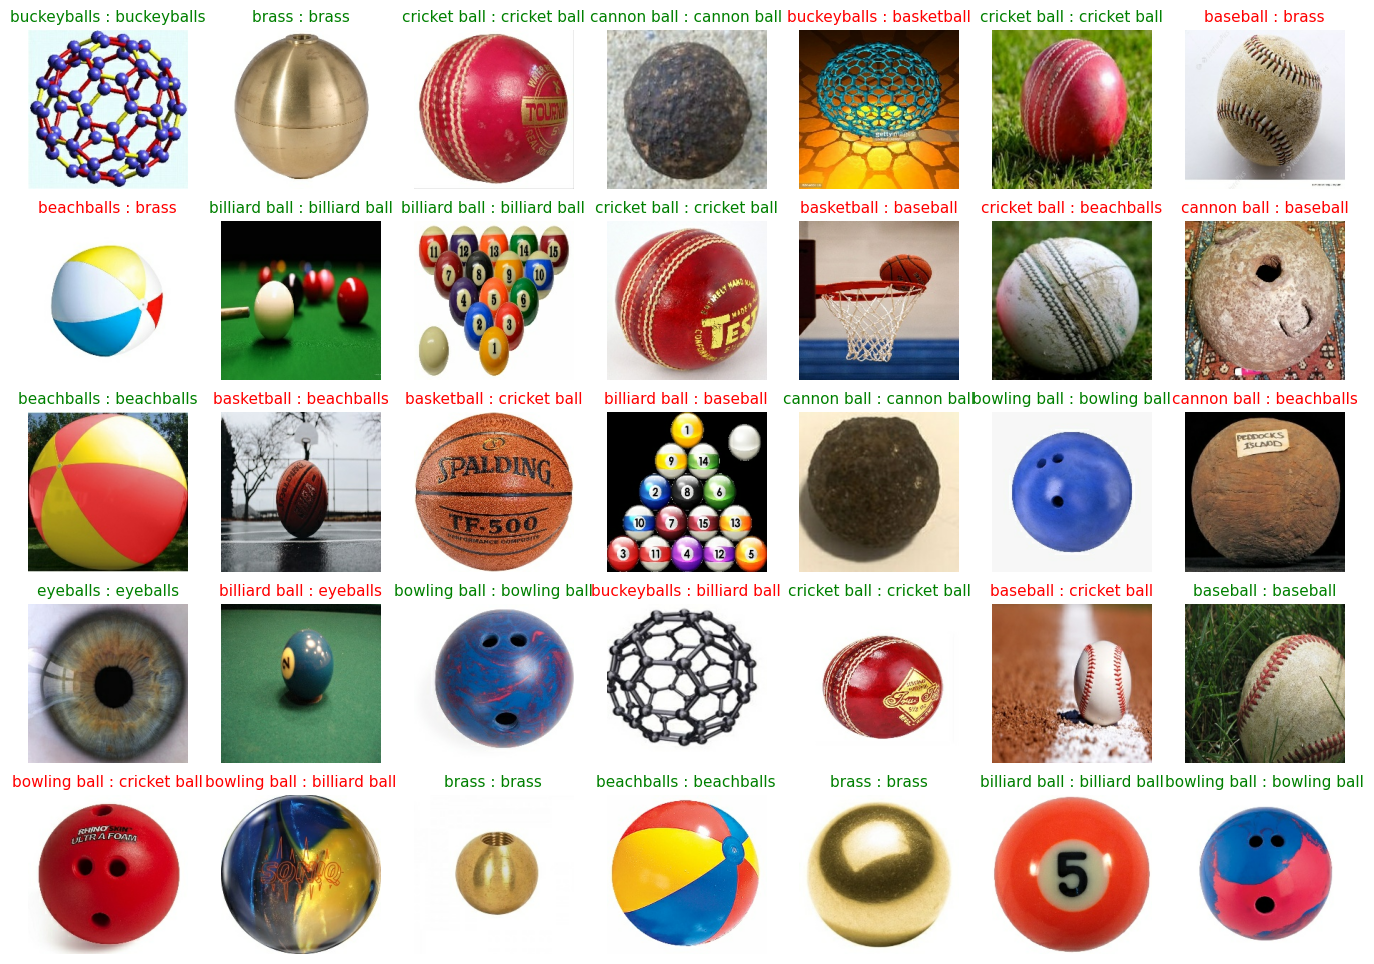

In [9]:
visualise_predictions(valid_dataset, model)

### Confusion Matrix

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step


/var/folders/ld/3fv056_n01n5d5f3v0ggq3hc0000gn/T/ipykernel_62889/2326391816.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  truths[index] = np.nonzero(labelsBatch[i].numpy())[0]


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 370ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 353ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


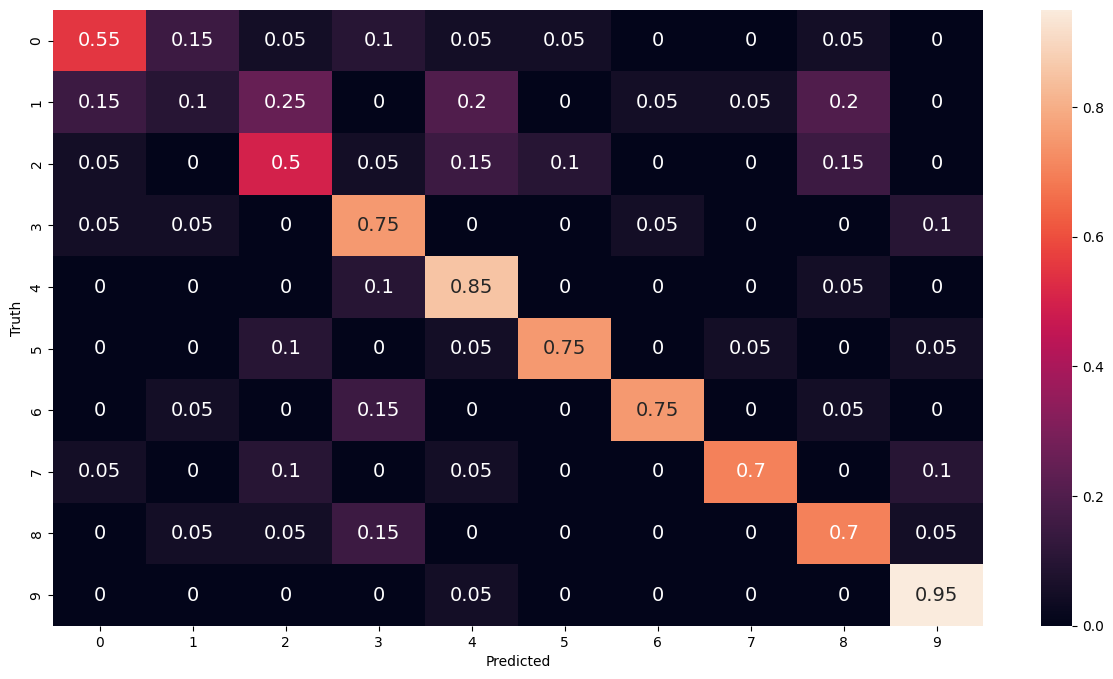

In [10]:
from sklearn.metrics import confusion_matrix

predictions = np.empty(shape=(200))
truths = np.empty(shape=(200))
index = 0
for dataBatch, labelsBatch in valid_dataset:
    pred = model.predict(dataBatch)
    for i in range(len(pred)):
        predictions[index] = tf.argmax(pred[i]).numpy()
        truths[index] = np.nonzero(labelsBatch[i].numpy())[0]
        index += 1

confMatrix = confusion_matrix(y_true=truths, y_pred=predictions, normalize="true")

plt.figure(figsize=[15, 8])
sn.heatmap(confMatrix, annot=True, annot_kws={"size": 14})
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

# Data Augmented Evaluations

In [11]:
# Import saved model
model = models.load_model("augmented_classification_model.keras")

In [12]:
valid_loss, valid_accuracy = model.evaluate(valid_dataset)
print(f"Validation Accuracy: {valid_accuracy}.3f")

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 413ms/step - accuracy: 0.7300 - loss: 0.8866
Validation Accuracy: 0.7300000190734863.3f


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step
Prediction accuracy:  0.71


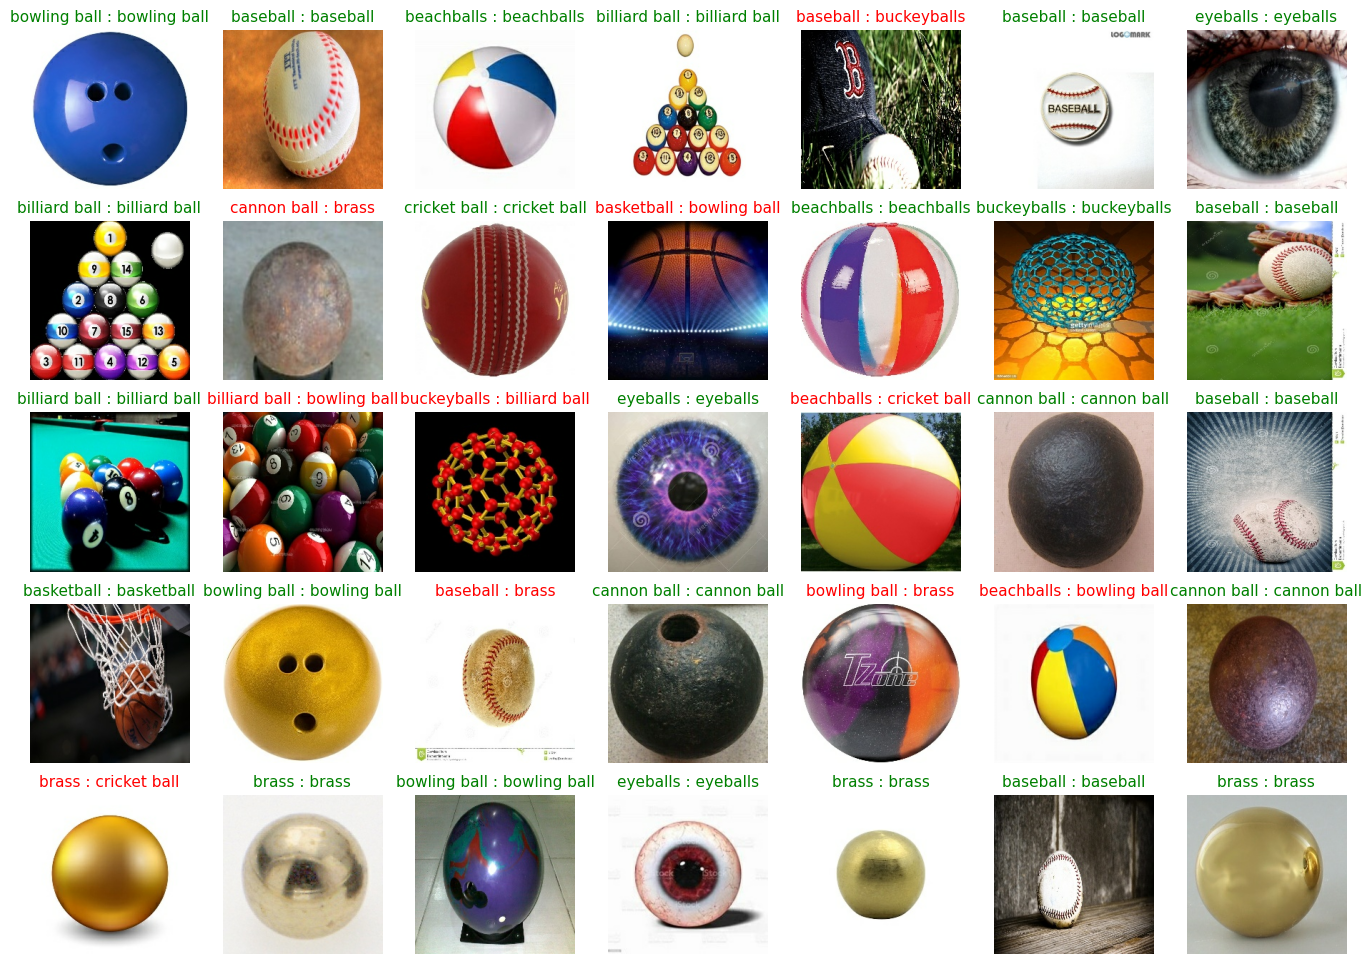

In [13]:
visualise_predictions(valid_dataset, model)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 255ms/step


/var/folders/ld/3fv056_n01n5d5f3v0ggq3hc0000gn/T/ipykernel_62889/2326391816.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  truths[index] = np.nonzero(labelsBatch[i].numpy())[0]


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 301ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


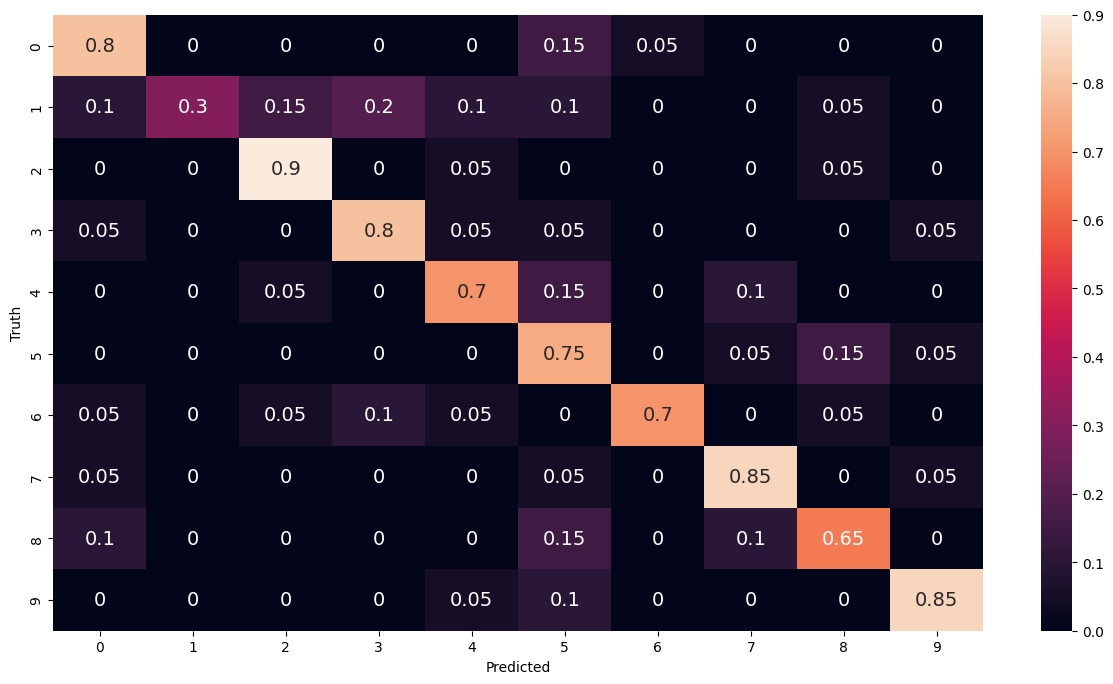

In [14]:
from sklearn.metrics import confusion_matrix

predictions = np.empty(shape=(200))
truths = np.empty(shape=(200))
index = 0
for dataBatch, labelsBatch in valid_dataset:
    pred = model.predict(dataBatch)
    for i in range(len(pred)):
        predictions[index] = tf.argmax(pred[i]).numpy()
        truths[index] = np.nonzero(labelsBatch[i].numpy())[0]
        index += 1

confMatrix = confusion_matrix(y_true=truths, y_pred=predictions, normalize="true")

plt.figure(figsize=[15, 8])
sn.heatmap(confMatrix, annot=True, annot_kws={"size": 14})
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()